# 0. Overview
- Dataset:
- Task: Regression
- Model: ANN
- Loss function: MSE
- Optimizer: SGD

In [19]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [20]:
if torch.cuda.is_available() == True:
    device = 'cuda:0'
    print("GPU available")
else:
    device = 'cpu'
    print("GPU not available")

GPU not available


# 1. Data Collection

In [21]:
gt_w = 4.56
gt_b = 7.89

# 10000 numbers from 0 ~ 10
x = torch.rand(10000, 1) * 10
y = gt_w * x + gt_b

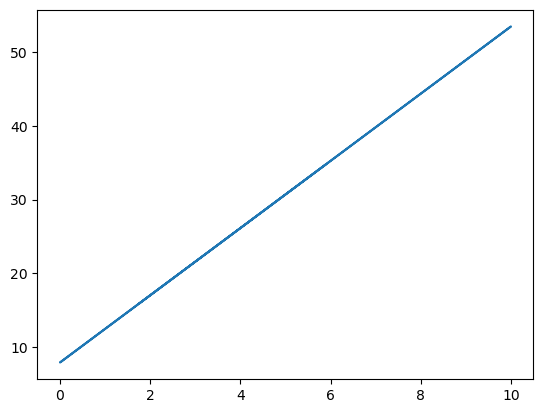

In [22]:
plt.plot(x, y)

# 2. Modelling

In [23]:
n_epochs = 3000
learning_rate = 1e-2
# If there is no improvement 30 epochs in a row, stop the training
patience = 30

In [24]:
class ANN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)


In [46]:
model = ANN(x.size(-1), y.size(-1))
optimizer = optim.SGD(model.parameters(), lr = learning_rate)
loss_fn = nn.MSELoss()

# 3. Model Training

In [47]:
losses = []
early_stop_cnt, weight_flag, bias_flag, last_epoch = 0, 0, 0, 0

for i in range(n_epochs):
    y_hat = model.forward(x)
    loss = loss_fn(y_hat, y)
    losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    #####

    w = float(model.linear.weight)
    b = float(model.linear.bias)

    print(f'Epoch {i} | Ground Truth equation: y = {gt_w}x + {gt_b} | predicted equation: y = {w}x + {b}')

    # 직전 epoch의 결과와 현재 예측된 결과의 비교에서 발전이 있는지 판단
    if w == weight_flag and b == bias_flag:
        early_stop_cnt += 1
    else:
        early_stop_cnt = 0

    if early_stop_cnt >= patience:
        print(f'Early stopping applied. The current epoch is {i}')
        last_epoch = i
        break

    # 다음 epoch에서 모델의 발전을 판단하기 위하여 예측된 weight랑 bias 저장
    weight_flag = w
    bias_flag = b


Epoch 0 | Ground Truth equation: y = 4.56x + 7.89 | predicted equation: y = 4.1752610206604x + 0.08716557174921036
Epoch 1 | Ground Truth equation: y = 4.56x + 7.89 | predicted equation: y = 5.207650184631348x + 0.28156426548957825
Epoch 2 | Ground Truth equation: y = 4.56x + 7.89 | predicted equation: y = 5.5370001792907715x + 0.369189977645874
Epoch 3 | Ground Truth equation: y = 4.56x + 7.89 | predicted equation: y = 5.639516353607178x + 0.42224106192588806
Epoch 4 | Ground Truth equation: y = 4.56x + 7.89 | predicted equation: y = 5.668857574462891x + 0.4640146493911743
Epoch 5 | Ground Truth equation: y = 4.56x + 7.89 | predicted equation: y = 5.674605369567871x + 0.5020287036895752
Epoch 6 | Ground Truth equation: y = 4.56x + 7.89 | predicted equation: y = 5.67275857925415x + 0.5387096405029297
Epoch 7 | Ground Truth equation: y = 4.56x + 7.89 | predicted equation: y = 5.6684794425964355x + 0.5748410224914551
Epoch 8 | Ground Truth equation: y = 4.56x + 7.89 | predicted equation:

# 3. Model Evaluation

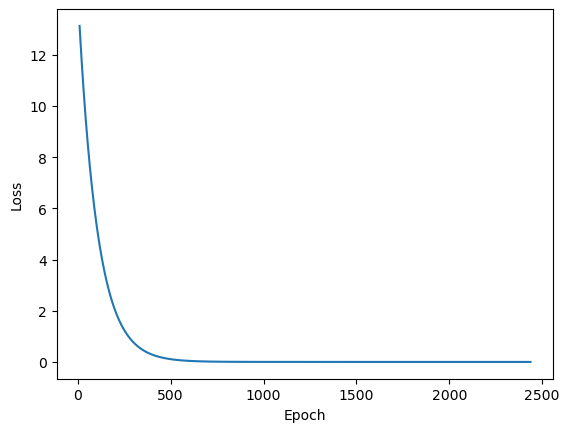

In [49]:
plt.plot(range(10, last_epoch+1, 1), losses[10:])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

# 5. Model Evaluation

## Use of the model

In [74]:
input = 123

input = float(input)
input = [input]
input = torch.tensor(input)

output = model(input)

ground_truth = input.item() * gt_w + gt_b
print(f'Ground Truth: {ground_truth:.3f}')
print(f'Predicted: {output.item():.3f}')

Ground Truth: 568.770
Predicted: 568.771


## Accuracy

### Test data set
- A prediction is considered a TP If it matches the groud truth up to the first decimal place

In [78]:
test_x = [[float(i)] for i in range(1000, 2000)]
test_y = [x[0] * gt_w + gt_b for x in test_x]

for i in range(10):
    print(f'x: {test_x[i]}, y: {test_y[i]}')

x: [1000.0], y: 4567.89
x: [1001.0], y: 4572.45
x: [1002.0], y: 4577.01
x: [1003.0], y: 4581.57
x: [1004.0], y: 4586.13
x: [1005.0], y: 4590.69
x: [1006.0], y: 4595.25
x: [1007.0], y: 4599.8099999999995
x: [1008.0], y: 4604.37
x: [1009.0], y: 4608.93


### Evaluate with the test dataset

In [80]:
true_cnt, false_cnt = 0, 0
predict = 'none'
print_list = []

for x, y in zip(test_x, test_y):
    y_pred = model(torch.tensor(x)).item()
    y_pred = round(y_pred, 1)
    y = round(y, 1)
    if y_pred == y:
        true_cnt += 1
        predict = 'Right'
    else:
        false_cnt += 1
        predict = 'Wrong'
    print_list.append(f'Ground Truth: {y}, Predicted: {y_pred} --> {predict}')

for txt, cnt in zip(print_list, range(1, len(print_list))):
    if cnt == 10 + 1:
        break
    print(f'{cnt}. {txt}')

1. Ground Truth: 4567.9, Predicted: 4567.9 --> Right
2. Ground Truth: 4572.4, Predicted: 4572.5 --> Wrong
3. Ground Truth: 4577.0, Predicted: 4577.0 --> Right
4. Ground Truth: 4581.6, Predicted: 4581.6 --> Right
5. Ground Truth: 4586.1, Predicted: 4586.1 --> Right
6. Ground Truth: 4590.7, Predicted: 4590.7 --> Right
7. Ground Truth: 4595.2, Predicted: 4595.3 --> Wrong
8. Ground Truth: 4599.8, Predicted: 4599.8 --> Right
9. Ground Truth: 4604.4, Predicted: 4604.4 --> Right
10. Ground Truth: 4608.9, Predicted: 4608.9 --> Right


In [81]:
acc = true_cnt / (true_cnt + false_cnt)
arr = round(acc, 3)

print(f'Accuracy: {acc}')

Accuracy: 0.825
